# 1.2 Metadata Dataset Exploratory Data Analysis

Dataset: Stroke Prediction Dataset

Purpose:
- Inspect columns
- Analyze class balance
- Identify missing values
- Identify categorical/numeric features
- Document preprocessing requirements

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from rural_stroke_assist.config import METADATA_DATA_DIR, FIGURES_DIR
from rural_stroke_assist.preprocessing.tabular import (
    summarize_missing_values,
    get_categorical_columns,
    get_numeric_columns,
    summarize_class_balance,
)
from rural_stroke_assist.plots import save_bar_plot

In [2]:
csv_files = list(METADATA_DATA_DIR.rglob("*.csv"))

csv_files

[WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/raw/stroke_prediction/healthcare-dataset-stroke-data.csv')]

In [3]:
metadata_df = pd.read_csv(csv_files[0])
metadata_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
metadata_df.shape

(5110, 12)

In [5]:
metadata_df.columns.tolist()

['id',
 'gender',
 'age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'avg_glucose_level',
 'bmi',
 'smoking_status',
 'stroke']

In [6]:
metadata_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [7]:
metadata_class_balance = summarize_class_balance(metadata_df, target_column="stroke")
metadata_class_balance

,count,percentage
stroke,,
0,4861,95.13
1,249,4.87


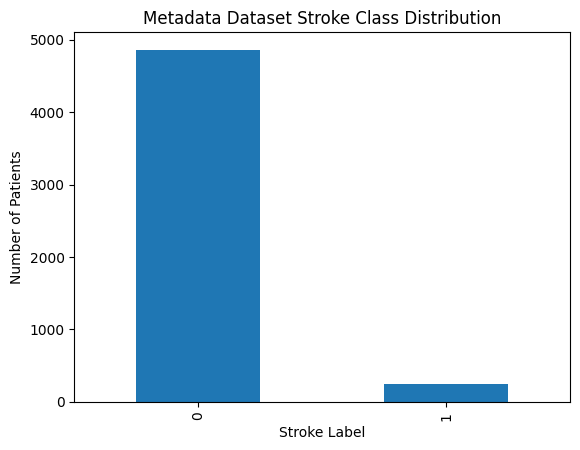

In [8]:
metadata_df["stroke"].value_counts().plot(kind="bar", title="Metadata Dataset Stroke Class Distribution")
plt.xlabel("Stroke Label")
plt.ylabel("Number of Patients")
plt.show()

In [9]:
from rural_stroke_assist.config import METADATA_DISTRIBUTION_PLOT_PATH

save_bar_plot(
    series=metadata_df["stroke"].value_counts(),
    title="Metadata Dataset Stroke Class Distribution",
    xlabel="Stroke Label",
    ylabel="Number of Patients",
    output_path=METADATA_DISTRIBUTION_PLOT_PATH,
)

In [10]:
missing_values = summarize_missing_values(metadata_df)
missing_values

,missing_count,missing_percentage
bmi,201,3.93
id,0,0.00
age,0,0.00
gender,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
work_type,0,0.00
ever_married,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00


In [11]:
categorical_columns = get_categorical_columns(metadata_df)
categorical_columns

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

In [12]:
numeric_columns = get_numeric_columns(metadata_df)
numeric_columns

['id',
 'age',
 'hypertension',
 'heart_disease',
 'avg_glucose_level',
 'bmi',
 'stroke']

In [13]:
metadata_df[numeric_columns].describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [14]:
for column in categorical_columns:
    print(f"\nColumn: {column}")
    print(metadata_df[column].value_counts(dropna=False))


Column: gender
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

Column: ever_married
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

Column: work_type
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Column: Residence_type
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

Column: smoking_status
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


In [15]:
from rural_stroke_assist.config import (
    METADATA_CLASS_BALANCE_PATH,
    METADATA_MISSING_VALUES_PATH,
)

# Ensure the parent directory (interim/) exists
METADATA_CLASS_BALANCE_PATH.parent.mkdir(parents=True, exist_ok=True)

# Save your dataframes using the explicit config paths
metadata_class_balance.to_csv(METADATA_CLASS_BALANCE_PATH)
missing_values.to_csv(METADATA_MISSING_VALUES_PATH)

print("Saved metadata EDA summaries using central configuration.")

Saved metadata EDA summaries using central configuration.


## Metadata Dataset Preprocessing Issues

Observed preprocessing issues:

1. Severe class imbalance  
   The stroke-positive class is much smaller than the non-stroke class. A naive model may predict the majority class too often.

2. Missing BMI values  
   Missing BMI values require imputation or row filtering.

3. Categorical encoding required  
   Columns such as gender, work type, residence type, smoking status, and marital status require encoding.

4. Feature scaling may be required  
   Age, average glucose level, and BMI have different numeric ranges.

5. Acute triage limitation  
   This dataset represents general stroke risk factors, not acute FAST-style prehospital triage.

6. Metadata module role  
   In this project, this dataset should support contextual risk scoring, not final diagnosis.